# K-Means Clustering


## Import Libraries


In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler


## Dataset Preparation


In [2]:
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)


## Preprocessing


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Elbow Method for Selecting K


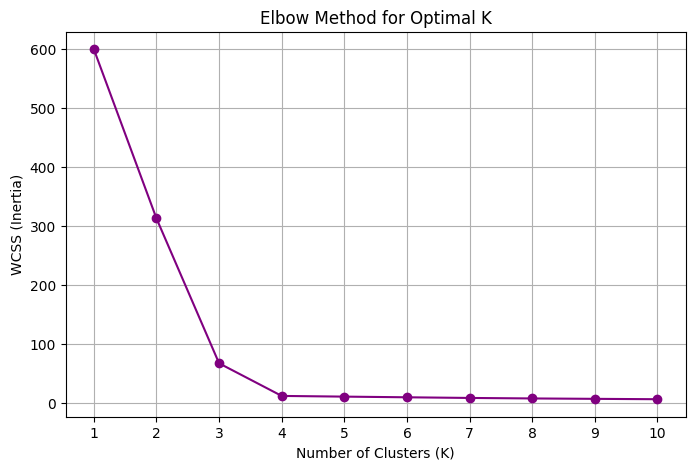

In [4]:
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker="o", color="purple")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_range)
plt.grid(True)
plt.show()


## Model Training


In [5]:
optimal_k = 4
model = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
cluster_labels = model.fit_predict(X_scaled)


## Cluster Assignment and Centroids


In [6]:
centroids = model.cluster_centers_
print("Cluster Assignments (first 10 samples):")
print(cluster_labels[:10])
print("\nCluster Centroids:")
print(centroids)


Cluster Assignments (first 10 samples):
[3 3 0 1 3 1 2 1 0 2]

Cluster Centroids:
[[ 0.14591084  0.99015106]
 [-0.65576768 -1.56289287]
 [ 1.54533333 -0.13223908]
 [-1.03547649  0.70498088]]


## Visualization of Clusters


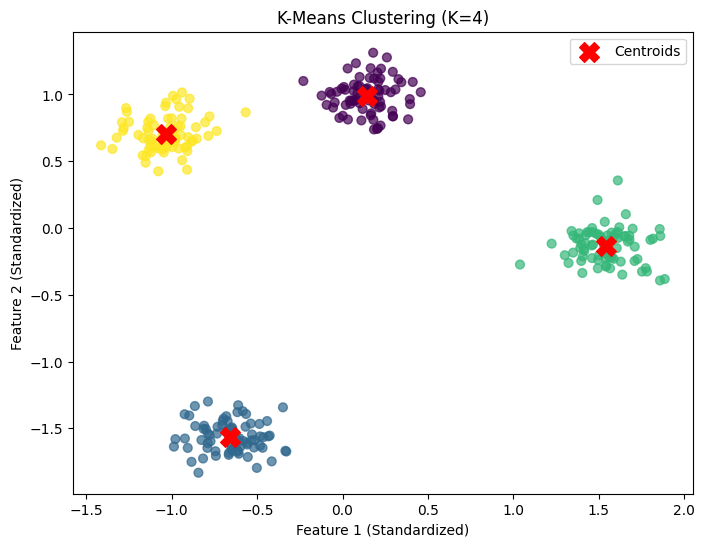

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap="viridis", s=40, alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X", label="Centroids")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.title("K-Means Clustering (K=4)")
plt.legend()
plt.show()
